# Trip Planner - Part 2: Human-in-the-Loop (the agent asks you)

Same Trip Planner project. This time the agent **proposes** destinations and waits for **your typed approval** before adding them. You can:

- type `yes` to accept the suggestion
- type `no` to skip it
- type `done` to finish and see the final plan
- type any city name to override the suggestion with your own pick

Under the hood: `langgraph.types.interrupt(...)` pauses the graph, we resume with `Command(resume=<your input>)`, and a conditional edge sends the agent back to suggest again until you say `done`.

Models: `gpt-4o-mini`. Secrets via Colab Secrets.

## 1. Install

In [1]:
%%capture --no-stderr
%pip install -qU langgraph langchain langchain-core langchain-openai pydantic

## 2. Load OPENAI_API_KEY from Colab secrets

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ.setdefault("LANGSMITH_TRACING", "false")
print("Key loaded:", bool(os.environ.get("OPENAI_API_KEY")))

Key loaded: True


## 3. State + suggestion LLM

The state tracks the destinations being built up, the suggestion currently waiting for your call, and a counter so we cannot suggest forever.

In [3]:
from typing import Annotated, TypedDict
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class TripState(TypedDict):
    messages: Annotated[list, add_messages]
    destinations: list[str]
    pending: str
    suggestions_made: int


class Suggestion(BaseModel):
    """A single city suggestion for the trip."""
    city: str = Field(description="A specific city name, e.g. 'Lisbon'")
    reason: str = Field(description="One short sentence on why it fits the trip")


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.4)
suggester = llm.with_structured_output(Suggestion)
print("LLM ready.")

LLM ready.


## 4. The three pieces of the graph

- `suggest` - generates one new city idea
- `review` - **pauses the graph** via `interrupt(...)`, waits for your input, then updates state based on what you typed
- `should_continue` - routes back to `suggest` for another round, or ends if you said `done`

In [4]:
from typing import Literal
from langgraph.types import interrupt, Command


def suggest(state: TripState) -> dict:
    current = state.get("destinations", [])
    user_seed = state["messages"][-1].content if state["messages"] else "a fun trip"

    prompt = (
        f"Plan a trip based on this idea: '{user_seed}'.\n"
        f"Cities already chosen: {current}.\n"
        "Suggest ONE NEW city (not in the list above) that complements them."
    )

    pick = suggester.invoke([SystemMessage(content=prompt)])

    return {
        "messages": [AIMessage(content=f"How about {pick.city}? {pick.reason}")],
        "pending": pick.city,
        "suggestions_made": state.get("suggestions_made", 0) + 1,
    }


def review(state: TripState) -> dict:
    pending = state["pending"]

    answer = interrupt({
        "question": f"Should I add {pending} to your trip?",
        "options": "yes | no | done | <type a different city to use instead>",
        "pending_city": pending,
        "current_plan": state.get("destinations", []),
    })

    choice = (answer or "").strip()
    lower = choice.lower()

    if lower in {"yes", "y"}:
        return {
            "destinations": state.get("destinations", []) + [pending],
            "messages": [AIMessage(content=f"Added {pending}.")],
            "pending": "",
        }
    if lower in {"no", "n", "skip"}:
        return {
            "messages": [AIMessage(content=f"Skipped {pending}.")],
            "pending": "",
        }
    if lower in {"done", "finish", "stop"}:
        return {
            "messages": [AIMessage(content="Wrapping up your plan.")],
            "pending": "__DONE__",
        }

    # Anything else = treat as a custom city name
    return {
        "destinations": state.get("destinations", []) + [choice],
        "messages": [AIMessage(content=f"Got it, added {choice} instead of {pending}.")],
        "pending": "",
    }


def should_continue(state: TripState) -> Literal["suggest", "__end__"]:
    if state.get("pending") == "__DONE__":
        return END
    if state.get("suggestions_made", 0) >= 6:
        return END  # hard cap so the loop always terminates
    return "suggest"


builder = StateGraph(TripState)
builder.add_node("suggest", suggest)
builder.add_node("review", review)
builder.add_edge(START, "suggest")
builder.add_edge("suggest", "review")
builder.add_conditional_edges("review", should_continue)

from langgraph.checkpoint.memory import MemorySaver
graph = builder.compile(checkpointer=MemorySaver())
print("Graph compiled.")

Graph compiled.


## 5. Visualize the graph

Notice the loop: `review` can route back to `suggest`.

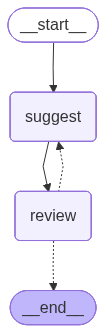

In [5]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## 6. The interactive runner

This is where it becomes a real conversation. Whenever the graph hits `interrupt(...)`, the result contains an `__interrupt__` payload. We show its question to you, take your typed answer with `input(...)`, and resume the graph with `Command(resume=<your answer>)`.

In [6]:
def run_planner(initial_idea: str, thread_id: str = "trip-1"):
    config = {"configurable": {"thread_id": thread_id}}

    state = graph.invoke(
        {
            "messages": [HumanMessage(content=initial_idea)],
            "destinations": [],
            "pending": "",
            "suggestions_made": 0,
        },
        config,
    )

    while state.get("__interrupt__"):
        info = state["__interrupt__"][0].value

        print()
        print("=" * 62)
        print(f"  AGENT: {info['question']}")
        print(f"  Options: {info['options']}")
        print(f"  Plan so far: {info['current_plan']}")
        print("=" * 62)

        user_answer = input("  YOU > ")

        state = graph.invoke(Command(resume=user_answer), config)

    print()
    print("#" * 62)
    print("  FINAL TRIP PLAN")
    print("#" * 62)
    print(f"  Destinations : {state.get('destinations', [])}")
    print(f"  Rounds used  : {state.get('suggestions_made', 0)}")
    return state

## 7. Plan a trip - the agent will ask you

Run the cell. The agent suggests cities one by one. Type `yes`, `no`, `done`, or your own city name. Try at least 3 rounds so you see the loop in action.

In [7]:
final_state = run_planner("a 10-day food-focused trip in southern Europe", thread_id="demo-1")


  AGENT: Should I add Barcelona to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: []
  YOU > yes

  AGENT: Should I add Valencia to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Barcelona']
  YOU > no

  AGENT: Should I add Seville to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Barcelona']
  YOU > no

  AGENT: Should I add Granada to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Barcelona']
  YOU > yes

  AGENT: Should I add Seville to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Barcelona', 'Granada']
  YOU > yes

  AGENT: Should I add Málaga to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Barcelona', 'Granada', 'Seville']
  YOU > yes

#####################################################

## 8. Bonus - the checkpointer means you can pause and come back

Because we compiled with `MemorySaver`, the trip you just built is saved under `demo-1`. Inspect it without running anything:

In [10]:
snapshot = graph.get_state({"configurable": {"thread_id": "demo-2"}})
print("Saved destinations on thread demo-1:", snapshot.values.get("destinations"))
print("Pending interrupt? ->", bool(snapshot.values.get("pending")))

Saved destinations on thread demo-1: ['Cusco', 'Machu Picchu']
Pending interrupt? -> False


## 9. Run again on a fresh thread

Use a different `thread_id` to start a brand new plan without losing the first one.

In [9]:
final_state = run_planner("a 5-day adventure trip in South America", thread_id="demo-2")


  AGENT: Should I add Cusco to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: []
  YOU > yes

  AGENT: Should I add Machu Picchu to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Cusco']
  YOU > yes

  AGENT: Should I add Ollantaytambo to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Cusco', 'Machu Picchu']
  YOU > no

  AGENT: Should I add Sacred Valley to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Cusco', 'Machu Picchu']
  YOU > no

  AGENT: Should I add Ollantaytambo to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Cusco', 'Machu Picchu']
  YOU > no

  AGENT: Should I add Sacred Valley to your trip?
  Options: yes | no | done | <type a different city to use instead>
  Plan so far: ['Cusco', 'Machu Picchu']
  YOU > no

###################

## Recap

| What you did | API |
|---|---|
| Paused the graph and waited for typed input | `interrupt({"question": ..., ...})` from `langgraph.types` |
| Resumed with the user's answer | `graph.invoke(Command(resume=answer), config)` |
| Looped back to ask again | conditional edge from `review` back to `suggest` |
| Hard-stopped if user said done | conditional edge returns `END` |
| Kept the plan around between rounds | `MemorySaver` checkpointer + `thread_id` |

Pair this with the Checkpoint notebook and you have the two foundations of every production LangGraph agent: durable state, and the ability to pause for a human.